# Vision Transformer Transfer Learning: Bean Leaf Classification

This notebook moves one step beyond the basic CNN workflow. We will fine-tune a pretrained Vision Transformer (ViT) on a small Hugging Face image classification dataset.

The main task is Hugging Face `AI-Lab-Makerere/beans`, a 3-class bean leaf dataset:

1. `angular_leaf_spot`
2. `bean_rust`
3. `healthy`

The model is `WinKawaks/vit-tiny-patch16-224`, a small ViT checkpoint. It is large enough to show the transformer workflow, but much lighter than ViT-Base for a classroom notebook.

## 1. Environment Setup

Local usage stays managed by uv from the project root:

```bash
uv run --with jupyter jupyter lab
```

For editor kernels or package installs from inside the notebook, create a project kernel first:

```bash
uv run ipython kernel install --user --env VIRTUAL_ENV $(pwd)/.venv --name=week2
```

On Google Colab, upload this notebook and run cells from the top. The setup cell below detects Colab, installs missing non-PyTorch dependencies into the active Colab runtime with `pip`, and intentionally leaves Colab's built-in `torch` and `torchvision` unchanged to avoid CUDA wheel mismatches.

In [1]:
import importlib.util
import subprocess
import sys


def in_colab() -> bool:
    try:
        return importlib.util.find_spec("google.colab") is not None
    except ModuleNotFoundError:
        return False


def module_available(module_name: str) -> bool:
    return importlib.util.find_spec(module_name) is not None


def run_command(command: list[str]) -> None:
    print("$ " + " ".join(command))
    subprocess.run(command, check=True)


def ensure_colab_dependencies() -> None:
    if not in_colab():
        print("Local environment detected: dependencies are expected from the uv project env.")
        return

    print("Google Colab detected: checking notebook dependencies.")
    missing_torch_modules = [
        name for name in ("torch", "torchvision") if not module_available(name)
    ]
    if missing_torch_modules:
        missing = ", ".join(missing_torch_modules)
        raise RuntimeError(
            f"Missing Colab PyTorch module(s): {missing}. "
            "Use a standard Colab runtime, or manually install matching torch/torchvision "
            "packages for the active CUDA runtime before continuing."
        )

    package_specs = {
        "datasets": "datasets[vision]",
        "matplotlib": "matplotlib",
        "tqdm": "tqdm",
        "transformers": "transformers",
    }
    missing_specs = [spec for module, spec in package_specs.items() if not module_available(module)]
    if not missing_specs:
        print("Colab dependencies are already available.")
        return

    run_command([sys.executable, "-m", "pip", "install", "-q", *missing_specs])


ensure_colab_dependencies()

Local environment detected: dependencies are expected from the uv project env.


In [2]:
import platform
import random
import time
from collections.abc import Mapping, Sequence

import matplotlib.pyplot as plt
import torch
from datasets import load_dataset
from torch import nn
from torch.utils.data import DataLoader
from torchvision import transforms
from tqdm.auto import tqdm
from transformers import AutoConfig, AutoImageProcessor, AutoModelForImageClassification

Metrics = dict[str, float | int]


def print_section(title: str, rows: Mapping[str, object]) -> None:
    label_width = max(len(label) for label in rows)
    print(f"\n{title}")
    print("-" * len(title))
    for label, value in rows.items():
        print(f"{label:<{label_width}} : {value}")


def format_shape(tensor: torch.Tensor) -> str:
    return " x ".join(str(size) for size in tensor.shape)


SEED = 42
random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

if torch.cuda.is_available():
    device = torch.device("cuda")
elif torch.backends.mps.is_available():
    device = torch.device("mps")
else:
    device = torch.device("cpu")

environment_name = "Google Colab" if in_colab() else "local uv"
print_section(
    "Runtime",
    {
        "Environment": environment_name,
        "Python": platform.python_version(),
        "PyTorch": torch.__version__,
        "Device": device,
        "Seed": SEED,
    },
)

/home/rvl/chiwei/summer_course/week2/.venv/lib/python3.14/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm



Runtime
-------
Environment : local uv
Python      : 3.14.0
PyTorch     : 2.12.1+cu126
Device      : cuda
Seed        : 42


## 2. Load the Beans Dataset

The Beans dataset is small enough for a quick transfer-learning exercise. It has separate train, validation, and test splits, so we can tune on validation data and keep test data for the final check.

In [3]:
raw_datasets = load_dataset("AI-Lab-Makerere/beans")
raw_datasets

DatasetDict({
    train: Dataset({
        features: ['image_file_path', 'image', 'labels'],
        num_rows: 1034
    })
    validation: Dataset({
        features: ['image_file_path', 'image', 'labels'],
        num_rows: 133
    })
    test: Dataset({
        features: ['image_file_path', 'image', 'labels'],
        num_rows: 128
    })
})


Beans dataset
-------------
Splits          : train, validation, test
Train rows      : 1,034
Validation rows : 133
Test rows       : 128
Classes         : 3 (angular_leaf_spot, bean_rust, healthy)
Example image   : RGB 500 x 500
Example label   : 0 = angular_leaf_spot


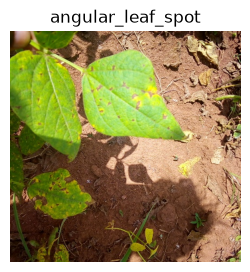

In [4]:
label_feature = raw_datasets["train"].features["labels"]
class_names = label_feature.names
num_classes = len(class_names)
raw_example = raw_datasets["train"][0]
example_image = raw_example["image"]
example_label = raw_example["labels"]

print_section(
    "Beans dataset",
    {
        "Splits": ", ".join(raw_datasets.keys()),
        "Train rows": f"{len(raw_datasets['train']):,}",
        "Validation rows": f"{len(raw_datasets['validation']):,}",
        "Test rows": f"{len(raw_datasets['test']):,}",
        "Classes": f"{num_classes} ({', '.join(class_names)})",
        "Example image": f"{example_image.mode} {example_image.width} x {example_image.height}",
        "Example label": f"{example_label} = {class_names[example_label]}",
    },
)

plt.figure(figsize=(3, 3))
plt.imshow(example_image)
plt.title(class_names[example_label])
plt.axis("off")
plt.show()

## 3. Image Processor and Transforms

Pretrained ViT checkpoints expect a specific image size and normalization range. Hugging Face image processors store those preprocessing choices with the model checkpoint.

We will use torchvision transforms for batching speed, but the resize size, channel mean, and channel standard deviation come from `AutoImageProcessor`.

In [5]:
model_name = "WinKawaks/vit-tiny-patch16-224"
image_processor = AutoImageProcessor.from_pretrained(model_name)

image_size = image_processor.size.get("height", image_processor.size.get("shortest_edge", 224))
image_mean = tuple(image_processor.image_mean)
image_std = tuple(image_processor.image_std)

print_section(
    "Image processor",
    {
        "Checkpoint": model_name,
        "Image size": f"{image_size} x {image_size}",
        "Mean": image_mean,
        "Std": image_std,
    },
)


Image processor
---------------
Checkpoint : WinKawaks/vit-tiny-patch16-224
Image size : 224 x 224
Mean       : (0.5, 0.5, 0.5)
Std        : (0.5, 0.5, 0.5)


In [6]:
train_transform = transforms.Compose(
    [
        transforms.RandomResizedCrop(image_size, scale=(0.75, 1.0)),
        transforms.RandomHorizontalFlip(),
        transforms.ToTensor(),
        transforms.Normalize(image_mean, image_std),
    ]
)

eval_transform = transforms.Compose(
    [
        transforms.Resize((image_size, image_size)),
        transforms.ToTensor(),
        transforms.Normalize(image_mean, image_std),
    ]
)


def transform_train(batch: dict[str, list]) -> dict[str, list]:
    batch["pixel_values"] = [
        train_transform(image.convert("RGB")) for image in batch["image"]
    ]
    return batch


def transform_eval(batch: dict[str, list]) -> dict[str, list]:
    batch["pixel_values"] = [
        eval_transform(image.convert("RGB")) for image in batch["image"]
    ]
    return batch


train_dataset = raw_datasets["train"].with_transform(transform_train)
validation_dataset = raw_datasets["validation"].with_transform(transform_eval)
test_dataset = raw_datasets["test"].with_transform(transform_eval)

In [7]:
def collate_fn(batch: list[dict[str, torch.Tensor | int]]) -> dict[str, torch.Tensor]:
    pixel_values = torch.stack([example["pixel_values"] for example in batch])
    labels = torch.tensor([example["labels"] for example in batch], dtype=torch.long)
    return {"pixel_values": pixel_values, "labels": labels}


def format_label_preview(labels: torch.Tensor, class_names: Sequence[str], limit: int = 8) -> str:
    pairs = [f"{label.item()}={class_names[label.item()]}" for label in labels[:limit]]
    return ", ".join(pairs)


batch_size = 32
pin_memory = device.type == "cuda"
num_workers = 0

train_loader = DataLoader(
    train_dataset,
    batch_size=batch_size,
    shuffle=True,
    collate_fn=collate_fn,
    num_workers=num_workers,
    pin_memory=pin_memory,
)

validation_loader = DataLoader(
    validation_dataset,
    batch_size=batch_size,
    shuffle=False,
    collate_fn=collate_fn,
    num_workers=num_workers,
    pin_memory=pin_memory,
)

test_loader = DataLoader(
    test_dataset,
    batch_size=batch_size,
    shuffle=False,
    collate_fn=collate_fn,
    num_workers=num_workers,
    pin_memory=pin_memory,
)

batch = next(iter(train_loader))
print_section(
    "Batch check",
    {
        "Pixel values": f"{format_shape(batch['pixel_values'])} ({batch['pixel_values'].dtype})",
        "Labels": f"{format_shape(batch['labels'])} ({batch['labels'].dtype})",
        "Preview": format_label_preview(batch["labels"], class_names),
        "Batch size": batch_size,
        "Pin memory": pin_memory,
    },
)
assert batch["pixel_values"].shape[1:] == (3, image_size, image_size)


Batch check
-----------
Pixel values : 32 x 3 x 224 x 224 (torch.float32)
Labels       : 32 (torch.int64)
Preview      : 1=bean_rust, 1=bean_rust, 0=angular_leaf_spot, 1=bean_rust, 0=angular_leaf_spot, 2=healthy, 1=bean_rust, 0=angular_leaf_spot
Batch size   : 32
Pin memory   : True


## 4. Visualize a Batch

The model receives normalized tensors. To display them, we undo normalization and convert tensors back to `[height, width, channels]` image arrays.

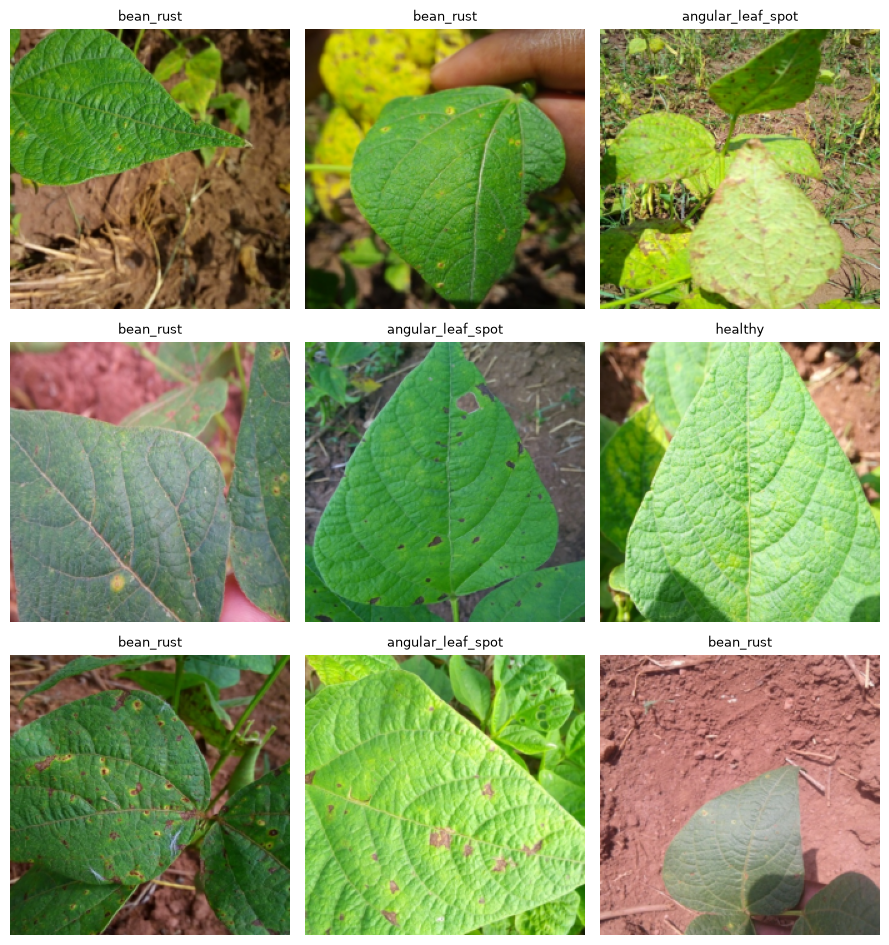

In [8]:
def denormalize(images: torch.Tensor) -> torch.Tensor:
    mean = torch.tensor(image_mean).view(1, 3, 1, 1)
    std = torch.tensor(image_std).view(1, 3, 1, 1)
    return (images.cpu() * std + mean).clamp(0, 1)


def show_images(
    images: torch.Tensor,
    labels: torch.Tensor,
    predictions: torch.Tensor | None = None,
    max_images: int = 9,
) -> None:
    display_images = denormalize(images[:max_images])
    display_labels = labels[:max_images].cpu()
    display_predictions = predictions[:max_images].cpu() if predictions is not None else None

    cols = 3
    rows = (len(display_images) + cols - 1) // cols
    _, axes = plt.subplots(rows, cols, figsize=(9, 3.2 * rows))
    axes = axes.flatten()

    for ax in axes:
        ax.axis("off")

    for i, image in enumerate(display_images):
        axes[i].imshow(image.permute(1, 2, 0))
        label_name = class_names[display_labels[i].item()]
        if display_predictions is None:
            title = label_name
        else:
            pred_name = class_names[display_predictions[i].item()]
            marker = "OK" if pred_name == label_name else "MISS"
            title = f"{marker}: {pred_name}\ntrue: {label_name}"
        axes[i].set_title(title, fontsize=9)

    plt.tight_layout()
    plt.show()


show_images(batch["pixel_values"], batch["labels"])


## 5. Load a Pretrained Tiny ViT

A pretrained image classifier usually has a classifier head for its original dataset. We keep the pretrained patch embedding and transformer blocks, but replace the classifier head with a new 3-class head for Beans.

`ignore_mismatched_sizes=True` tells Transformers to load all compatible pretrained weights and reinitialize only the classifier tensors whose shape changed.

In [9]:
id2label = {idx: name for idx, name in enumerate(class_names)}
label2id = {name: idx for idx, name in id2label.items()}

config = AutoConfig.from_pretrained(model_name)
config.num_labels = num_classes
config.id2label = id2label
config.label2id = label2id

model = AutoModelForImageClassification.from_pretrained(
    model_name,
    config=config,
    ignore_mismatched_sizes=True,
).to(device)


def count_parameters(model: nn.Module, trainable_only: bool = True) -> int:
    parameters = model.parameters()
    if trainable_only:
        parameters = (parameter for parameter in parameters if parameter.requires_grad)
    return sum(parameter.numel() for parameter in parameters)


with torch.inference_mode():
    logits = model(pixel_values=batch["pixel_values"].to(device)).logits

print_section(
    "Tiny ViT classifier",
    {
        "Model class": model.__class__.__name__,
        "Total params": f"{count_parameters(model, trainable_only=False):,}",
        "Trainable params": f"{count_parameters(model):,}",
        "Input batch": format_shape(batch["pixel_values"]),
        "Output logits": format_shape(logits),
    },
)
assert logits.shape == (batch["pixel_values"].size(0), num_classes)

Loading weights: 100%|██████████| 200/200 [00:00<00:00, 7716.29it/s]
[transformers] ViTForImageClassification LOAD REPORT from: WinKawaks/vit-tiny-patch16-224
Key               | Status   |                                                                                          
------------------+----------+------------------------------------------------------------------------------------------
classifier.weight | MISMATCH | Reinit due to size mismatch - ckpt: torch.Size([1000, 192]) vs model:torch.Size([3, 192])
classifier.bias   | MISMATCH | Reinit due to size mismatch - ckpt: torch.Size([1000]) vs model:torch.Size([3])          

Notes:
- MISMATCH:	ckpt weights were loaded, but they did not match the original empty weight shapes.



Tiny ViT classifier
-------------------
Model class      : ViTForImageClassification
Total params     : 5,524,995
Trainable params : 5,524,995
Input batch      : 32 x 3 x 224 x 224
Output logits    : 32 x 3


## 6. Inside ViT: Images as Patch Tokens

This checkpoint uses `16 x 16` image patches. A `224 x 224` image becomes a `14 x 14` patch grid:

- `224 / 16 = 14` patches per side
- `14 * 14 = 196` image patch tokens
- ViT prepends one learned `[CLS]` token
- the transformer sees `197` tokens total

The classifier uses the final `[CLS]` representation to predict the image class.

In [10]:
patch_size = model.config.patch_size
hidden_size = model.config.hidden_size
patches_per_side = image_size // patch_size
num_patch_tokens = patches_per_side * patches_per_side
num_tokens_with_cls = num_patch_tokens + 1

with torch.inference_mode():
    embeddings = model.vit.embeddings(batch["pixel_values"].to(device))

print_section(
    "ViT tokenization",
    {
        "Image size": f"{image_size} x {image_size}",
        "Patch size": f"{patch_size} x {patch_size}",
        "Patch grid": f"{patches_per_side} x {patches_per_side}",
        "Patch tokens": num_patch_tokens,
        "Tokens with CLS": num_tokens_with_cls,
        "Embedding size": hidden_size,
        "Embedding tensor": format_shape(embeddings),
    },
)
assert embeddings.shape == (batch["pixel_values"].size(0), num_tokens_with_cls, hidden_size)


ViT tokenization
----------------
Image size       : 224 x 224
Patch size       : 16 x 16
Patch grid       : 14 x 14
Patch tokens     : 196
Tokens with CLS  : 197
Embedding size   : 192
Embedding tensor : 32 x 197 x 192


## 7. Training and Evaluation Helpers

The loop is still ordinary PyTorch. The main difference from a CNN is the input key: Hugging Face image models expect `pixel_values`, and the forward pass returns an object with a `.logits` tensor.

In [11]:
def accuracy_from_logits(logits: torch.Tensor, labels: torch.Tensor) -> torch.Tensor:
    predictions = logits.argmax(dim=1)
    return (predictions == labels).sum()


def dataloader_steps(dataloader: DataLoader, max_batches: int | None = None) -> int:
    steps = len(dataloader)
    return steps if max_batches is None else min(steps, max_batches)


def progress_postfix(
    total_loss: torch.Tensor, total_correct: torch.Tensor, total_examples: int
) -> dict[str, str]:
    return {
        "loss": f"{total_loss.item() / total_examples:.4f}",
        "acc": f"{total_correct.item() / total_examples:.2%}",
    }


def run_epoch(
    model: nn.Module,
    dataloader: DataLoader,
    loss_fn: nn.Module,
    device: torch.device,
    optimizer: torch.optim.Optimizer | None = None,
    max_batches: int | None = None,
    description: str = "epoch",
) -> Metrics:
    model.train(optimizer is not None)
    total_loss = torch.zeros((), device=device)
    total_correct = torch.zeros((), device=device)
    total_examples = 0
    start = time.perf_counter()
    steps = dataloader_steps(dataloader, max_batches)
    progress = tqdm(dataloader, total=steps, desc=description, leave=False)

    with torch.set_grad_enabled(optimizer is not None):
        for batch_idx, batch in enumerate(progress):
            if max_batches is not None and batch_idx >= max_batches:
                break

            pixel_values = batch["pixel_values"].to(device, non_blocking=True)
            labels = batch["labels"].to(device, non_blocking=True)

            logits = model(pixel_values=pixel_values).logits
            loss = loss_fn(logits, labels)

            if optimizer is not None:
                optimizer.zero_grad(set_to_none=True)
                loss.backward()
                optimizer.step()

            batch_size = labels.size(0)
            total_loss += loss.detach() * batch_size
            total_correct += accuracy_from_logits(logits, labels)
            total_examples += batch_size
            if batch_idx % 20 == 0:
                progress.set_postfix(progress_postfix(total_loss, total_correct, total_examples))

    return {
        "loss": total_loss.item() / total_examples,
        "accuracy": total_correct.item() / total_examples,
        "examples": total_examples,
        "seconds": time.perf_counter() - start,
    }


def train_model(
    model: nn.Module,
    train_dataloader: DataLoader,
    validation_dataloader: DataLoader,
    loss_fn: nn.Module,
    optimizer: torch.optim.Optimizer,
    device: torch.device,
    epochs: int,
    max_train_batches: int | None = None,
) -> list[dict[str, Metrics]]:
    history = []
    for epoch in range(1, epochs + 1):
        train_metrics = run_epoch(
            model,
            train_dataloader,
            loss_fn,
            device,
            optimizer=optimizer,
            max_batches=max_train_batches,
            description=f"epoch {epoch}/{epochs} train",
        )
        validation_metrics = run_epoch(
            model,
            validation_dataloader,
            loss_fn,
            device,
            description=f"epoch {epoch}/{epochs} validation",
        )
        epoch_metrics = {"train": train_metrics, "validation": validation_metrics}
        history.append(epoch_metrics)
        print_section(
            f"Epoch {epoch}",
            {
                "Train loss": f"{train_metrics['loss']:.4f}",
                "Train accuracy": f"{train_metrics['accuracy']:.2%}",
                "Validation loss": f"{validation_metrics['loss']:.4f}",
                "Validation accuracy": f"{validation_metrics['accuracy']:.2%}",
                "Seconds": f"{train_metrics['seconds'] + validation_metrics['seconds']:.1f}",
            },
        )
    return history

## 8. Stage 1: Train Only the Classifier Head

Freezing the pretrained ViT body makes training much cheaper. The transformer still computes image features, but only the small classifier head receives gradient updates.

In [12]:
def set_trainable(module: nn.Module, trainable: bool) -> None:
    for parameter in module.parameters():
        parameter.requires_grad = trainable


def trainable_parameter_summary(model: nn.Module) -> dict[str, object]:
    trainable_names = [name for name, parameter in model.named_parameters() if parameter.requires_grad]
    preview = ", ".join(trainable_names[:6])
    if len(trainable_names) > 6:
        preview += ", ..."
    return {
        "Trainable tensors": len(trainable_names),
        "Trainable params": f"{count_parameters(model):,}",
        "Preview": preview,
    }


set_trainable(model, False)
set_trainable(model.classifier, True)

summary = trainable_parameter_summary(model)
print_section("Frozen ViT setup", summary)
assert all(
    parameter.requires_grad == name.startswith("classifier.")
    for name, parameter in model.named_parameters()
)


Frozen ViT setup
----------------
Trainable tensors : 2
Trainable params  : 579
Preview           : classifier.weight, classifier.bias


In [13]:
head_epochs = 1
loss_fn = nn.CrossEntropyLoss()
optimizer = torch.optim.AdamW(model.classifier.parameters(), lr=3e-4, weight_decay=1e-4)

head_history = train_model(
    model,
    train_loader,
    validation_loader,
    loss_fn,
    optimizer,
    device,
    epochs=head_epochs,
)


Epoch 1
-------
Train loss          : 0.9568
Train accuracy      : 52.71%
Validation loss     : 0.7092
Validation accuracy : 74.44%
Seconds             : 5.3


## 9. Optional Stage 2: Fine-Tune the Last Transformer Blocks

After the classifier head learns the new labels, we can unfreeze the last transformer blocks with a smaller learning rate. This is more expensive than training only the head, so the cell below is disabled by default.

Set `run_partial_finetuning = True` when you have a GPU or want to see the next transfer-learning step.

In [14]:
def unfreeze_last_vit_blocks(model: nn.Module, num_blocks: int) -> None:
    set_trainable(model, False)
    set_trainable(model.classifier, True)
    for block in model.vit.layers[-num_blocks:]:
        set_trainable(block, True)
    set_trainable(model.vit.layernorm, True)


run_partial_finetuning = False
fine_tune_history = []

if run_partial_finetuning:
    unfreeze_last_vit_blocks(model, num_blocks=2)
    print_section("Partial fine-tuning setup", trainable_parameter_summary(model))
    optimizer = torch.optim.AdamW(
        [parameter for parameter in model.parameters() if parameter.requires_grad],
        lr=5e-5,
        weight_decay=1e-4,
    )
    fine_tune_history = train_model(
        model,
        train_loader,
        validation_loader,
        loss_fn,
        optimizer,
        device,
        epochs=1,
    )
else:
    print("Partial fine-tuning skipped. Set run_partial_finetuning = True to run it.")

Partial fine-tuning skipped. Set run_partial_finetuning = True to run it.


## 10. Final Test Evaluation

The test split is held out until the end. This gives a cleaner estimate of how well the trained model generalizes beyond the examples used during training and validation.

In [15]:
test_metrics = run_epoch(model, test_loader, loss_fn, device, description="test")
print_section(
    "Test metrics",
    {
        "Loss": f"{test_metrics['loss']:.4f}",
        "Accuracy": f"{test_metrics['accuracy']:.2%}",
        "Examples": test_metrics["examples"],
        "Seconds": f"{test_metrics['seconds']:.1f}",
    },
)


Test metrics
------------
Loss     : 0.7376
Accuracy : 64.84%
Examples : 128
Seconds  : 0.6


## 11. Predictions and Top-k Probabilities

The model returns logits. For display, we apply `softmax` after the model to convert logits into probabilities.


First test image probabilities
------------------------------
bean_rust         : 51.81%
angular_leaf_spot : 35.73%
healthy           : 12.46%


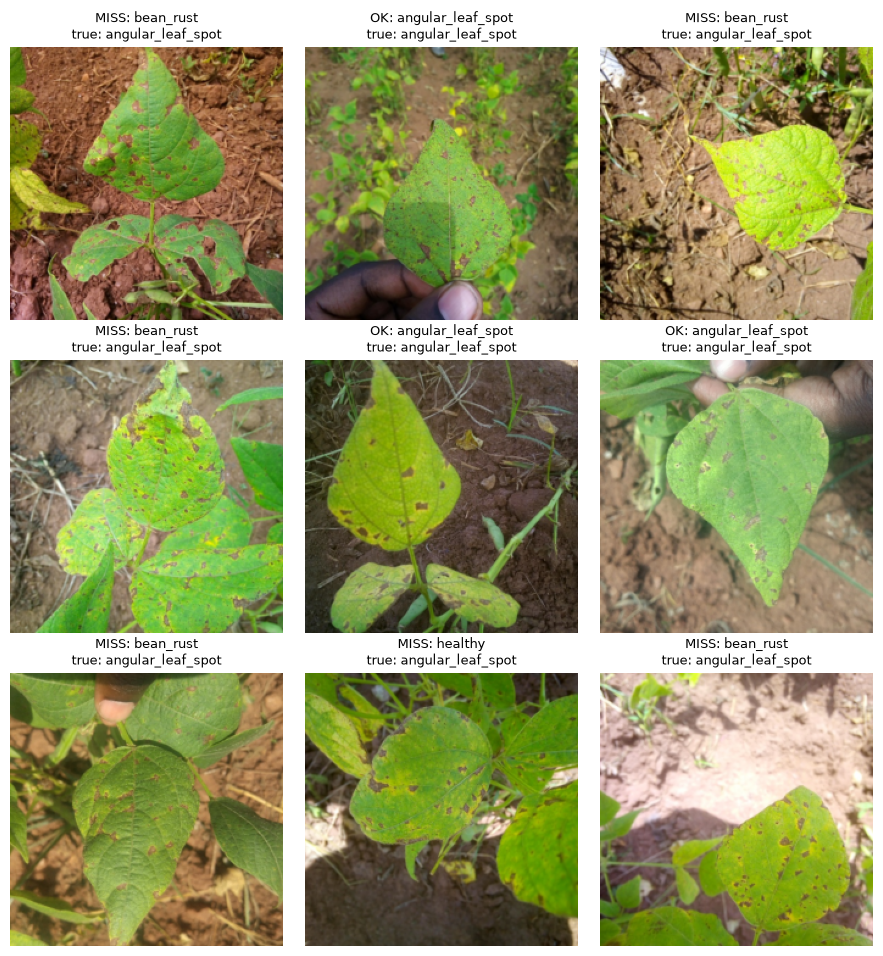

In [16]:
@torch.inference_mode()
def predict_batch(
    model: nn.Module,
    batch: dict[str, torch.Tensor],
    device: torch.device,
) -> tuple[torch.Tensor, torch.Tensor]:
    model.eval()
    logits = model(pixel_values=batch["pixel_values"].to(device)).logits
    probabilities = torch.softmax(logits, dim=1)
    predictions = probabilities.argmax(dim=1)
    return predictions.cpu(), probabilities.cpu()


test_batch = next(iter(test_loader))
predictions, probabilities = predict_batch(model, test_batch, device)

top_scores, top_indices = torch.topk(probabilities[0], k=num_classes)
print_section(
    "First test image probabilities",
    {
        class_names[class_idx.item()]: f"{score.item():.2%}"
        for score, class_idx in zip(top_scores, top_indices, strict=True)
    },
)

show_images(
    test_batch["pixel_values"],
    test_batch["labels"],
    predictions=predictions,
    max_images=9,
)

## 12. Optional Save Pattern

This notebook does not save weights by default because model checkpoints are large and should not be committed accidentally. If you want to keep a local checkpoint, uncomment the cell below and save into `notebooks/models/`.

In [17]:
# from pathlib import Path
#
# model_dir = Path("models")
# model_dir.mkdir(exist_ok=True)
# weights_path = model_dir / "vit_tiny_beans.pt"
# torch.save(model.state_dict(), weights_path)
# print(f"Saved model weights to {weights_path}")

## What You Should Be Ready For Next

After this notebook, you should understand these ideas:

- A pretrained vision model can be reused by replacing only its classifier head.
- Hugging Face image processors define the resize and normalization expected by a checkpoint.
- ViT treats an image as a sequence of patch tokens plus a `[CLS]` token.
- Freezing most pretrained weights makes transfer learning faster and less data-hungry.
- Partial fine-tuning unfreezes a small number of transformer blocks when you need more adaptation.